<a href="https://colab.research.google.com/github/ademimi2008/spam_task/blob/main/spamm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Данные варианта 1 (спам-фильтр)
TP, FN, FP, TN = 51, 24, 7, 168

def metrics(TP, FN, FP, TN):
    total = TP + FN + FP + TN
    accuracy  = (TP + TN) / total
    precision = TP / (TP + FP)
    recall    = TP / (TP + FN)
    f1 = 2 * precision * recall / (precision + recall)
    return accuracy, precision, recall, f1

def show_matrix(TP, FN, FP, TN, title):
    m = np.array([[TP, FN], [FP, TN]])
    fig, ax = plt.subplots(figsize=(4, 3.5))
    ax.imshow(m, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Спам', 'Не спам'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Спам', 'Не спам'])
    ax.set_xlabel('Прогноз модели'); ax.set_ylabel('Факт')
    ax.set_title(title)
    labels = [['TP', 'FN'], ['FP', 'TN']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{labels[i][j]}\n{m[i, j]}', ha='center', va='center',
                    color='white' if m[i, j] > m.max() / 2 else 'black', fontsize=12)
    plt.tight_layout(); plt.show()

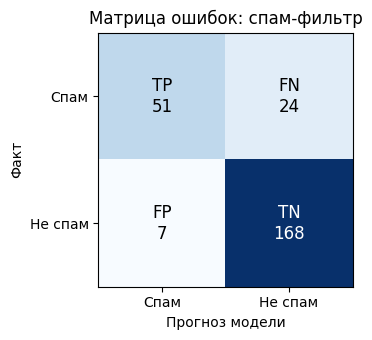

In [9]:
show_matrix(TP, FN, FP, TN, 'Матрица ошибок: спам-фильтр')

In [10]:
desc = pd.DataFrame({
    'Ячейка': ['TP', 'FN', 'FP', 'TN'],
    'Значение': [TP, FN, FP, TN],
    'Что означает в сценарии': [
        'Спам, который фильтр правильно отправил в папку «Спам»',
        'Спам, который фильтр пропустил: письмо попало во «Входящие»',
        'Нормальное письмо, ошибочно отправленное в «Спам»',
        'Нормальное письмо, которое правильно осталось во «Входящих»'
    ]
})
display(desc)

,Ячейка,Значение,Что означает в сценарии
0,TP,51,"Спам, который фильтр правильно отправил в папк..."
1,FN,24,"Спам, который фильтр пропустил: письмо попало ..."
2,FP,7,"Нормальное письмо, ошибочно отправленное в «Спам»"
3,TN,168,"Нормальное письмо, которое правильно осталось ..."


In [11]:
total = TP + FN + FP + TN
accuracy, precision, recall, f1 = metrics(TP, FN, FP, TN)
specificity = TN / (TN + FP)

res = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1'],
    'Формула': ['(TP+TN)/(TP+TN+FP+FN)', 'TP/(TP+FP)', 'TP/(TP+FN)',
                'TN/(TN+FP)', '2·P·R/(P+R)'],
    'Значение': [accuracy, precision, recall, specificity, f1]
}).round(3)
display(res)

,Метрика,Формула,Значение
0,Accuracy,(TP+TN)/(TP+TN+FP+FN),0.876
1,Precision,TP/(TP+FP),0.879
2,Recall,TP/(TP+FN),0.680
3,Specificity,TN/(TN+FP),0.960
4,F1,2·P·R/(P+R),0.767


In [12]:
acc_dummy = (FP + TN) / total
print(f"Accuracy нашей модели:        {accuracy:.3f}")
print(f"Accuracy модели 'всегда нет': {acc_dummy:.3f}")
print(f"Доля спама в данных:          {(TP + FN) / total:.0%}")

Accuracy нашей модели:        0.876
Accuracy модели 'всегда нет': 0.700
Доля спама в данных:          30%


Новая матрица: 73 2 43 132 | сумма: 250


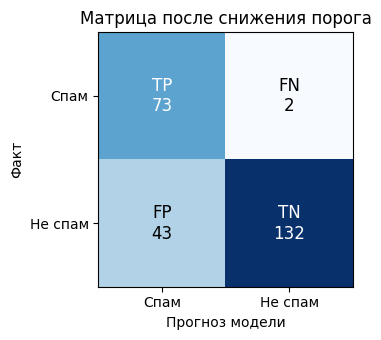

,Accuracy,Precision,Recall,F1
До сдвига,0.876,0.879,0.680,0.767
После сдвига,0.820,0.629,0.973,0.764


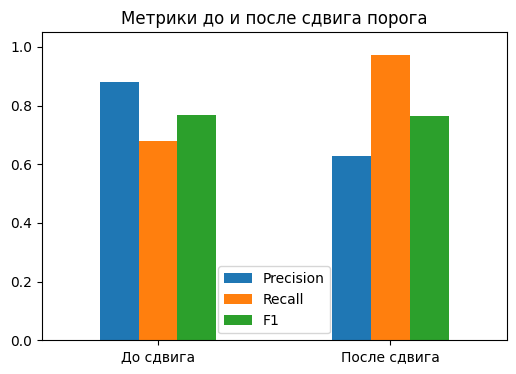

In [13]:
TP2, FN2, FP2, TN2 = TP + 22, FN - 22, FP + 36, TN - 36
print("Новая матрица:", TP2, FN2, FP2, TN2, "| сумма:", TP2 + FN2 + FP2 + TN2)

show_matrix(TP2, FN2, FP2, TN2, 'Матрица после снижения порога')

df = pd.DataFrame([metrics(TP, FN, FP, TN), metrics(TP2, FN2, FP2, TN2)],
                  index=['До сдвига', 'После сдвига'],
                  columns=['Accuracy', 'Precision', 'Recall', 'F1']).round(3)
display(df)

df[['Precision', 'Recall', 'F1']].plot(kind='bar', figsize=(6, 4), ylim=(0, 1.05))
plt.title('Метрики до и после сдвига порога')
plt.xticks(rotation=0); plt.show()